Relação estado reuso: 
{2: 3, 3: 2, 4: 1}


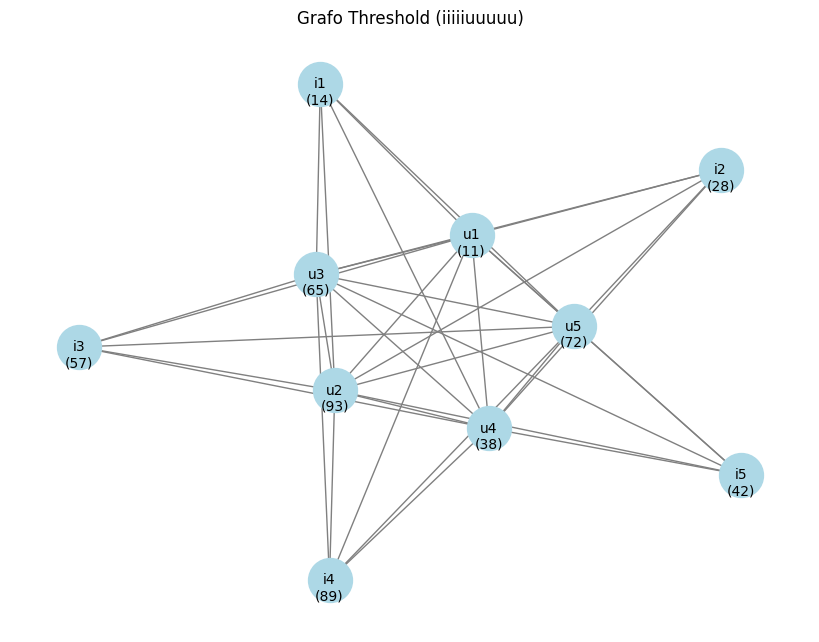

Graph with 10 nodes and 35 edges
PROGRAMAÇÃO DINÂMICA:
Iniciou às 2026-07-01 17:58:59.080


In [ ]:
from geracao_grafos import *
from abordagemGulosa import *
from egl import *
from problemasPolinomiais.gulosoBicoloridoCiclo import *
from problemasPolinomiais.gulosoCompleto import *
from problemasPolinomiais.gulosoKmn import *
from problemasPolinomiais.gulosoArvore import *
from funcoesDP import *
from valG import *
from pympler import asizeof
#!pip install pympler

from otimizacoesPD.caminho_otimizado_pd import *
import gc
import sys


def mainSemDp(grafo, pesos):
    
    inicio_tempo = time.time()
    melhor_valor, melhor_caminho = valor(grafo, pesos)
    fim_tempo = time.time()
    print("Sem Programação Dinâmica:")
    print("Melhor caminho:", melhor_caminho)
    print("Tempo de execução:", fim_tempo - inicio_tempo, "segundos")
    calcular_ganhos(melhor_caminho, pesos)
    imprimirArvoreDecisao(arvore_decisao,False)


def w3():
    G = nx.Graph()
    edges = [('a', 'b'), ('b', 'c'),('a', 'c'),('a', 'd'), ('b', 'd'),('c', 'd') ]
    #edges = [('v4', 'v3'), ('v3', 'v2'), ('v2', 'v1')]

    G.add_edges_from(edges)
    weights = {'a': 3, 'b': 5, 'c': 1,'d':2}

    return G,weights



def mainEGL(grafo, pesos):
    inicio_tempo = time.time()
    memo = {}
    timestamp = datetime.datetime.now().strftime("%Y-%m-%d %H:%M:%S.%f")[:-3]  # Mantém milissegundos
  # Captura o instante de reutilização
    print(f"Iniciou às {timestamp}")
    melhor_valor_dp, melhor_caminho_dp = abordagemEGL(grafo, pesos)
    fim_tempo = time.time()
    
    print("Tempo de execução EGL:", fim_tempo - inicio_tempo, "segundos")


def mainDP_Classes(grafo, pesos):
    limparVariaveisGlobais()
    inicio_tempo = time.time()
    memo = {}
    timestamp = datetime.datetime.now().strftime("%Y-%m-%d %H:%M:%S.%f")[:-3]
    print(f"Iniciou às {timestamp}")
    melhor_valor_dp, melhor_caminho_dp = valor_dp_classes(grafo, pesos, memo, inicio_tempo)
    fim_tempo = time.time()
    print("\nCom DP + Classes de Vizinhança:")
    print("Melhor valor:", melhor_valor_dp)
    print("Melhor caminho:", melhor_caminho_dp)
    print("Tempo de execução:", fim_tempo - inicio_tempo, "segundos")
    quantidade_estados = contar_estados(grafo)
    print("Quantidade de estados a serem gerados:", quantidade_estados)
    print("Número de entradas na tabela dinâmica:", len(memo))
    print("Tamanho total do memo (real):", asizeof.asizeof(memo), "bytes")
    print("Número de reusos:", len(contagem_reuso_dp))
    print("Número de estados distintos usados:", len(estados_reusados))
    calcular_ganhos(melhor_caminho_dp, pesos)
    return logs_memo, qtd_estados_plot


def mainGuloso(grafo, pesos):
    inicio_tempo = time.time()
    memo = {}
    timestamp = datetime.datetime.now().strftime("%Y-%m-%d %H:%M:%S.%f")[:-3]  # Mantém milissegundos
  # Captura o instante de reutilização
    print(f"Iniciou às {timestamp}")
    melhor_valor_dp, melhor_caminho_dp = abordagemGulosa(grafo, pesos)
    fim_tempo = time.time()
    
    print("Tempo de execução:", fim_tempo - inicio_tempo, "segundos")
    
def mainClasses(grafo, pesos):
    inicio_tempo = time.time()
    melhor_valor, melhor_caminho = valor_classes(grafo, pesos)
    fim_tempo = time.time()
    print("\nAbordagem por Classes de Vizinhança:")
    print("Melhor valor:", melhor_valor)
    print("Melhor caminho:", melhor_caminho)
    print("Tempo de execução:", fim_tempo - inicio_tempo, "segundos")
    calcular_ganhos(melhor_caminho, pesos)    

    
def mainDP(grafo, pesos):
    limparVariaveisGlobais()
    inicio_tempo = time.time()
    memo = {}
    timestamp = datetime.datetime.now().strftime("%Y-%m-%d %H:%M:%S.%f")[:-3]  # Mantém milissegundos
  # Captura o instante de reutilização
    print("PROGRAMAÇÃO DINÂMICA:")
    print(f"Iniciou às {timestamp}")
    melhor_valor_dp, melhor_caminho_dp = valor_dp(grafo, pesos, memo,inicio_tempo)
    fim_tempo = time.time()
    print("\nCom Programação Dinâmica :")
    print("Melhor caminho:", melhor_caminho_dp)
    print("Tempo de execução:", fim_tempo - inicio_tempo, "segundos")
    quantidade_estados = contar_estados(grafo)
    print("Quantidade de estados  a serem gerados:", quantidade_estados)
    print("Número de entradas na tabela dinâmica:", len(memo))
    print("Tamanho total do memo (real):", asizeof.asizeof(memo), "bytes")
    print("Número de reusos:", len(contagem_reuso_dp))
    print("Número de estados distintos usados: ",len(estados_reusados))
    calcular_ganhos(melhor_caminho_dp, pesos)
    #imprime_estados_reusados()
    #imprime_estados_nao_reutilizados(memo)
    #imprime_tabela_dp(memo)

    return logs_memo,qtd_estados_plot
    #imprimirArvoreDecisao(arvore_decisao_dp)

def mainDP_Bipartido(grafo, pesos,m,n):
    inicio_tempo = time.time()
    memo = {}
    timestamp = datetime.datetime.now().strftime("%Y-%m-%d %H:%M:%S.%f")[:-3]  # Mantém milissegundos
  # Captura o instante de reutilização
    print(f"Iniciou às {timestamp}")
    melhor_valor_dp, melhor_caminho_dp = valor_dp_bipartido(grafo, pesos, memo,m,n,inicio_tempo)
    #melhor_valor_dp, melhor_caminho_dp = valor_dp_bipartido_LIMPO(grafo, pesos, memo,m,n)
    fim_tempo = time.time()
    print("\nCom Programação Dinâmica Kmn Otimizado:")
    print("Melhor caminho:", melhor_caminho_dp)
    print("Tempo de execução:", fim_tempo - inicio_tempo, "segundos")
    quantidade_estados = contar_estados(grafo)
    print("Quantidade de estados  a serem gerados:", quantidade_estados)
    print("Número de entradas na tabela dinâmica:", len(memo))
    print("Tamanho total do memo (real):", asizeof.asizeof(memo), "bytes")
    print("Número de reusos:", len(contagem_reuso_dp))
    print("Número de estados distintos usados: ",len(estados_reusados))
    calcular_ganhos(melhor_caminho_dp, pesos)
    #imprime_estados_reusados()
    #imprime_estados_nao_reutilizados(memo)
    return logs_memoKmn,qtd_estados_plotKmn
    #imprime_tabela_dp(memo)
    #imprimirArvoreDecisao(arvore_decisao_dp)


def mainDP_Caminho(grafo, pesos):
    primeirosVerticesViaveis = verticesViaveis(grafo)
    primeirosVerticesNaoViaveis = grafo.nodes - primeirosVerticesViaveis

    inicio_tempo = time.time()
    memo = {}
    timestamp = datetime.datetime.now().strftime("%Y-%m-%d %H:%M:%S.%f")[:-3]  # Mantém milissegundos
  # Captura o instante de reutilização
    print(f"Iniciou às {timestamp}")
    melhor_valor_dp, melhor_caminho_dp = valor_dp_caminho(grafo, pesos, primeirosVerticesNaoViaveis,memo,inicio_tempo)
    #melhor_valor_dp, melhor_caminho_dp = valor_dp_caminho_LIMPO(grafo, pesos, primeirosVerticesNaoViaveis,memo)

    
    fim_tempo = time.time()
    print("\nCom Programação Dinâmica Pn Otimizado:")
    print("Melhor caminho:", melhor_caminho_dp)
    print("Tempo de execução:", fim_tempo - inicio_tempo, "segundos")
    quantidade_estados = contar_estados(grafo)
    print("Quantidade de estados  a serem gerados:", quantidade_estados)
    print("Número de entradas na tabela dinâmica:", len(memo))
    print("Tamanho total do memo (real):", asizeof.asizeof(memo), "bytes")
    print("Número de reusos:", len(contagem_reuso_dp))
    print("Número de estados distintos usados: ",len(estados_reusados))
    calcular_ganhos(melhor_caminho_dp, pesos)
    imprime_estados_reusados()
    imprime_estados_nao_reutilizados(memo)
    return logs_memoKmn,qtd_estados_plotKmn
    #imprime_tabela_dp(memo)
    #imprimirArvoreDecisao(arvore_decisao_dp)


def subdivisao_losango(G, weights):
    """
    Aplica subdivisão losango em cada aresta (u, v):
        u — uv1 — v
        u — uv2 — v
    Os novos vértices uv1 e uv2 recebem o peso do menor entre
    weights[u] e weights[v].
    """
    G_sub = nx.Graph()
    new_weights = {}

    # Mantém os vértices originais e seus pesos
    for node, w in weights.items():
        new_weights[node] = w

    # Para cada aresta, cria o losango com pesos herdados do menor vértice
    for u, v in G.edges():
        mid1 = f"{u}{v}1"
        mid2 = f"{u}{v}2"

        # Peso herdado do menor entre u e v
        menor_peso = min(weights[u], weights[v])

        # Adiciona arestas do losango
        G_sub.add_edges_from([
            (u, mid1), (mid1, v),
            (u, mid2), (mid2, v)
        ])

        # Define pesos
        new_weights[mid1] = menor_peso
        new_weights[mid2] = menor_peso

    return G_sub, new_weights


def subdivisao_expansao(G, weights, n):
    """
    Aplica subdivisão por expansão de caminho em cada aresta (u, v):
        Cada aresta é substituída por um caminho de tamanho n,
        inserindo n vértices intermediários com peso 0.

        Exemplo com n=2: u — m1 — m2 — v
        Exemplo com n=3: u — m1 — m2 — m3 — v

    Se n=0, o grafo permanece inalterado.
    """
    n = n +1
    if n < 1:
        raise ValueError("O tamanho do caminho n deve ser >= 1.")

    G_sub = nx.Graph()
    new_weights = {}

    # Mantém os vértices originais e seus pesos
    for node in G.nodes():
        new_weights[node] = weights[node]

    for u, v in G.edges():
        if n == 1:
            # Sem subdivisão, mantém a aresta original
            G_sub.add_edge(u, v)
        else:
            # Cria n-1 vértices intermediários com peso 0
            intermediarios = [f"{u}_{v}_{i}" for i in range(1, n)]

            # Monta o caminho: u — m1 — m2 — ... — m(n-1) — v
            caminho = [u] + intermediarios + [v]
            for i in range(len(caminho) - 1):
                G_sub.add_edge(caminho[i], caminho[i + 1])

            # Atribui peso 0 a todos os intermediários
            for m in intermediarios:
                new_weights[m] = 0

    return G_sub, new_weights


def main():
    gc.collect()  # Força a coleta de lixo
    m, n = 3,3
    altura = 3
    gerar_reuso_estados(m, n)


    #mainGulosoKmn(grafo,pesos)
    #mainGulosoArvore(grafo,pesos)

    #mainDP( grafo, pesos)
    contagem_reuso_dp = []
    
    print("==================================================================================================")
    print("==================================================================================================")
    #mainDP_Bipartido(grafo,pesos,m,n)
    #mainDP_Caminho(grafo,pesos)
    print("==================================================================================================")
    print("==================================================================================================")
    #plotar_evolucao_memo(logs_memo,logs_memoKmn)
    #plotar_evolucaoQtdEstados_memo(qtd_estados_plot,qtd_estados_plotKmn)
    
    #grafo, pesos = p4()
    #grafo, pesos = teste()
    grafo, pesos = c4()
    #grafo, pesos = grafoSimples()
    
    #grafoC, pesos2 = gerar_grafo_ciclo(4)      # Gera um ciclo de 5 nós
    #grafo, pesos = gerar_grafo_completo(3)   # Gera um grafo completo de 6 nós
    #grafo, pesos = gerar_grafo_caminho(20)    # Gera um caminho de 4 nós
    #grafo, pesos = fig3_egawa()
    #grafo, pesos, conjunto_x, conjunto_y = criar_grafo_bipartido(m, n)
    #grafo, pesos, conjunto_x, conjunto_y = criar_grafo_bipartido_completo(m, n)

    #grafo, pesos = gerar_arvore_par(16)    
    #grafo, pesos = arvoreCompleta(altura)
    #grafo, pesos = w3()
    #grafo, pesos = p3() 
    #grafo, pesos = p5_Contraexemplo_PreservaVencedor()
    
    #G3, w3, ponte = unir_por_ponte(G1, w1, G2, w2, u='c', v='d')
    #grafop2, pesosP2 = p2()
    #G3, w3, ponte = unir_por_ponte(grafo, pesos, grafop2, pesosP2, u='c1',v='p0')

    #grafo,pesos = book(7,100,100)
    #grafo,pesos = gerar_grafo_barbell(3,3)
    #grafo,pesos = gerar_contraexemplo_barbell()
    #grafoExpansao, pesosExpansao = subdivisao_expansao(grafo, pesos, 2)
    #grafoComPendentes, novoPesos = adicionar_pendentes_nulos(grafo, pesos)
    #grafoLosango, pesosLosango = subdivisao_losango(grafo,pesos)

    
    #plot_graph(grafoExpansao, pesosExpansao,'Após expansão')
    #plot_graph(grafoComPendentes, novoPesos,'Após Adição de Pendentes')
    #plot_graph(grafo, pesos,'Sem subdivisão')
    #plot_graph(grafoLosango, pesosLosango,'Subdivisão losango')
    #grafo, pesos = gerar_grafo_threshold('iiiiiiuuuuuu',[14, 28, 57, 89, 42, 11, 93, 65, 72, 38, 50, 81])
    grafo, pesos = gerar_grafo_threshold('iiiiiuuuuu',[14, 28, 57, 89, 42, 11,93,65,38,72])

    #grafo, pesos = gerar_grafo_threshold('iuiu',[14, 11, 50, 81])
    print(grafo)
    #mainGuloso(grafo,pesos)
    #mainEGL(grafo,pesos)
    #mainDP_Classes(grafo, pesos)
    #mainDP( grafop2, pesosP2)
    
    mainDP( grafo, pesos)
    grafo2, pesos2 = removeGemos(grafo, pesos, apenas_isopesos=False)
    plot_graph(grafo2, pesos2, f"Grafo Apos remoção gemeos")

    print(grafo2)
    mainDP(grafo2,pesos2)
    #mainDP( G3, w3)
    #mainDP(grafoLosango,pesosLosango)
    #mainDP( grafoExpansao, pesosExpansao)
    #mainSemDp( grafo, pesos)
    #mainBicoloracaoCaminho( grafo, pesos)
    #mainGulosoCompleto(grafo,pesos)
    #mainGulosoBicoloridoCiclo(grafo,pesos)

if __name__ == "__main__":
    main()